# Phase 4 — forecasting and chronological validation

This restart-and-run notebook explains the frozen, leakage-controlled Phase 4 workflow. Reusable modeling, validation, changepoint, plotting, and safety logic lives in `src/geotech_ts/`; this notebook orchestrates and inspects its aggregate outputs. USGS observations remain in ignored Parquet layers.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from geotech_ts.phase4_validation import validate_phase4_outputs

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
TABLES = PROJECT_ROOT / 'reports/tables/phase4'
FIGURES = PROJECT_ROOT / 'reports/figures/phase4'
PROCESSED = PROJECT_ROOT / 'data/processed/cleveland_corral'
print('Project root resolved without displaying a machine-specific path.')

Project root resolved without displaying a machine-specific path.


## Reproduce or verify

A clean local checkout can regenerate Phase 4 from the verified Phase 2 and Phase 3 local layers. Set `FORCE_PHASE4_REBUILD=1` to force the full rolling fit; otherwise existing deterministic outputs are validated. Notebook validation is deferred until this execution finishes.

In [2]:
forecast_output = PROCESSED / 'phase4_rolling_forecasts.parquet'
force_rebuild = os.environ.get('FORCE_PHASE4_REBUILD') == '1'
if force_rebuild or not forecast_output.exists():
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / 'scripts/build_phase4_analysis.py')],
        cwd=PROJECT_ROOT,
        check=True,
    )

errors = validate_phase4_outputs(
    PROJECT_ROOT, require_local_processed=True, require_executed_notebook=False
)
assert errors == [], '\n'.join(errors)
print('Phase 4 tables, figures, and local processed outputs validated.')

Phase 4 tables, figures, and local processed outputs validated.


## Contract and target windows

The contract was frozen before model comparison. Targets are Phase 3 eligible daily displacement first differences. Origins occur every 14 calendar days on fixed anchors; they are never moved to make a forecast possible. Training expands through the origin only, while the target path must stay eligible within one segment and water year.

In [3]:
display(pd.read_csv(TABLES / 'analysis_configuration.csv'))
display(pd.read_csv(TABLES / 'target_windows.csv'))
display(pd.read_csv(TABLES / 'model_specifications.csv'))

,parameter,value
0,contract_frozen,2026-08-27 before Phase 4 model comparison
1,time_zone,fixed PST (UTC-08:00) local calendar dates
2,targets,Phase 3 eligible daily first differences for m...
3,horizons_days,1;2;7
4,origin_schedule,"every 14 calendar days on fixed, never-shifted..."
5,minimum_training,365 calendar days and 300 eligible target obse...
6,window_rule,expanding complete daily calendar; missing tar...
7,core_origin_rule,eligible origin-through-target path inside one...
8,primary_metric,MAE
9,secondary_metrics,RMSE;bias;training-only MASE


,window_id,target_id,role,start_date,end_date_inclusive,history_start_date,origin_anchor_date,origin_stride_days,calendar_day_count,eligible_target_change_count,first_eligible_target_date,last_eligible_target_date,selection_end_date
0,middle_stable_2009_2016,mid_E2_B,primary,2009-02-12,2016-01-21,2009-02-12,2010-02-12,14,2535,2389,2009-02-13,2016-01-21,2013-08-31
1,toe_pre_topple_long,toe_E5_C,secondary_primary_window,2006-11-30,2016-01-21,2006-11-30,2007-11-30,14,3340,3211,2006-12-01,2016-01-21,2012-12-31
2,toe_pre_topple_post_rain_resume,toe_E5_C,external_time_check,2016-01-28,2017-03-15,2006-11-30,2016-01-28,14,413,367,2016-01-28,2017-03-15,not_applicable


,model_id,family,order,seasonal_order,targets,horizons_days,exogenous_feature,complexity_rank,rationale
0,zero_change,baseline,not_applicable,not_applicable,mid_E2_B;toe_E5_C,1;2;7,none,1,target-scale no-change reference
1,expanding_median,baseline,not_applicable,not_applicable,mid_E2_B;toe_E5_C,1;2;7,none,2,robust expanding historical center
2,persistence,baseline,not_applicable,not_applicable,mid_E2_B;toe_E5_C,1;2;7,none,3,last eligible displacement change
3,prior_year_same_date,baseline,not_applicable,not_applicable,mid_E2_B;toe_E5_C,1;2;7,none,4,exact prior-calendar-year seasonal reference
4,arima_mean,ARIMA,"(0, 0, 0)","(0, 0, 0, 0)",mid_E2_B;toe_E5_C,1;2;7,none,5,white-noise mean model
5,arima_ar1,ARIMA,"(1, 0, 0)","(0, 0, 0, 0)",mid_E2_B;toe_E5_C,1;2;7,none,6,parsimonious short-memory model
6,arima_ar2,ARIMA,"(2, 0, 0)","(0, 0, 0, 0)",mid_E2_B;toe_E5_C,1;2;7,none,7,limited second-lag model
7,arima_arma11,ARIMA,"(1, 0, 1)","(0, 0, 0, 0)",mid_E2_B;toe_E5_C,1;2;7,none,8,limited ARMA alternative
8,arima_ar1_weekly,ARIMA,"(1, 0, 0)","(1, 0, 0, 7)",mid_E2_B,1;2;7,none,9,middle weekly-memory sensitivity
9,arimax_ar1_rain_lag2,conditional_ARIMAX,"(1,0,0)",none,toe_E5_C,1;2 (7 unavailable by contract),eligible daily interval rain at target lag 2,10,Phase 3 toe rain-to-change association at two ...


## Frozen selection versus later evaluation

Selection uses only the earlier declared stage and identical common origins. Later evaluation never changes the retained model. Positive paired MAE differences mean that a candidate performed worse than zero change. The key result is negative: the zero-change baseline, tied with the expanding median, has the lowest later MAE at all six target/horizon combinations.

,window_id,target_id,horizon_days,retained_model_id,selection_reason,selection_eligible_candidates,selection_common_origin_count,retained_selection_common_origin_mae,retained_evaluation_mae,evaluation_best_observed_model_id,evaluation_best_observed_mae,evaluation_does_not_revise_selection,external_time_check_forecast_count,external_time_check_retained_mae
0,middle_stable_2009_2016,mid_E2_B,1,zero_change,lowest_common_origin_mae_with_five_percent_com...,arima_ar1;arima_ar1_weekly;arima_ar2;arima_arm...,78,0.252564,0.056311,expanding_median,0.056311,True,0,NaN
1,middle_stable_2009_2016,mid_E2_B,2,arima_ar1,lowest_common_origin_mae_with_five_percent_com...,arima_ar1;arima_ar1_weekly;arima_ar2;arima_arm...,76,0.213241,0.113926,expanding_median,0.069508,True,0,NaN
2,middle_stable_2009_2016,mid_E2_B,7,arima_ar2,lowest_common_origin_mae_with_five_percent_com...,arima_ar1;arima_ar1_weekly;arima_ar2;arima_arm...,73,0.141585,0.105134,expanding_median,0.069440,True,0,NaN
3,toe_pre_topple_long,toe_E5_C,1,persistence,lowest_common_origin_mae_with_five_percent_com...,arima_ar1;arima_ar2;arima_arma11;arima_mean;ar...,97,0.350515,0.202632,expanding_median,0.114474,True,26,0.223077
4,toe_pre_topple_long,toe_E5_C,2,arima_arma11,lowest_common_origin_mae_with_five_percent_com...,arima_ar1;arima_ar2;arima_arma11;arima_mean;ar...,96,0.386771,0.200651,expanding_median,0.156579,True,26,0.239948
5,toe_pre_topple_long,toe_E5_C,7,arima_arma11,lowest_common_origin_mae_with_five_percent_com...,arima_ar1;arima_ar2;arima_arma11;arima_mean;ex...,96,0.322557,0.153515,expanding_median,0.114583,True,25,0.279402


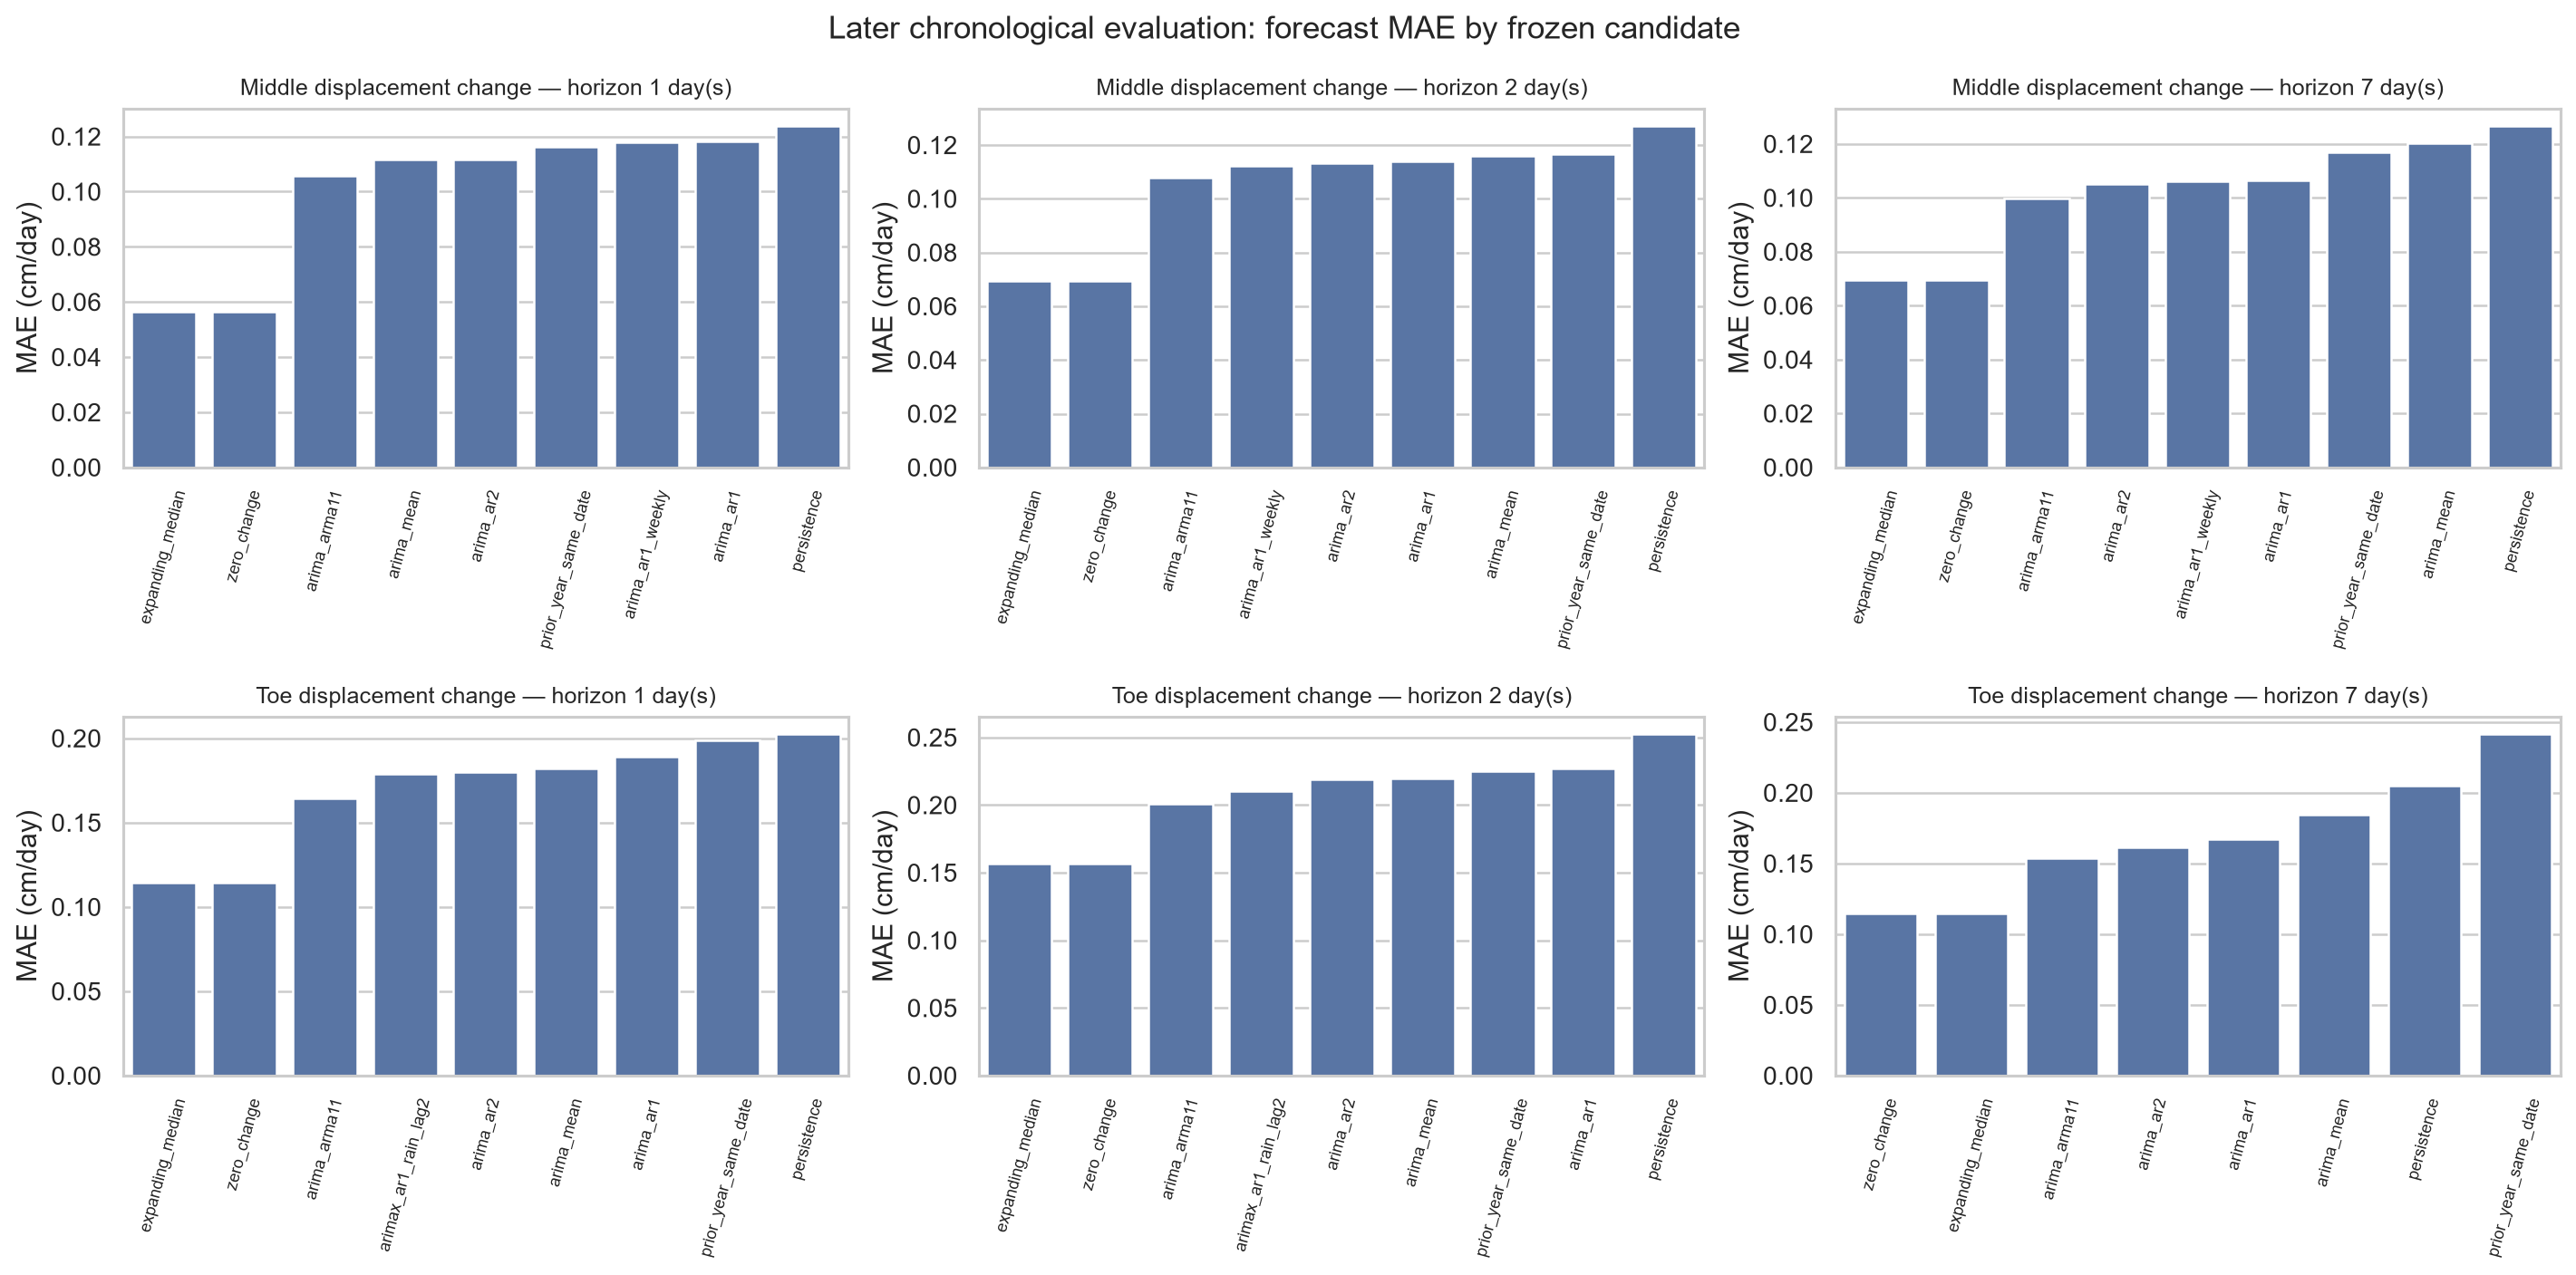

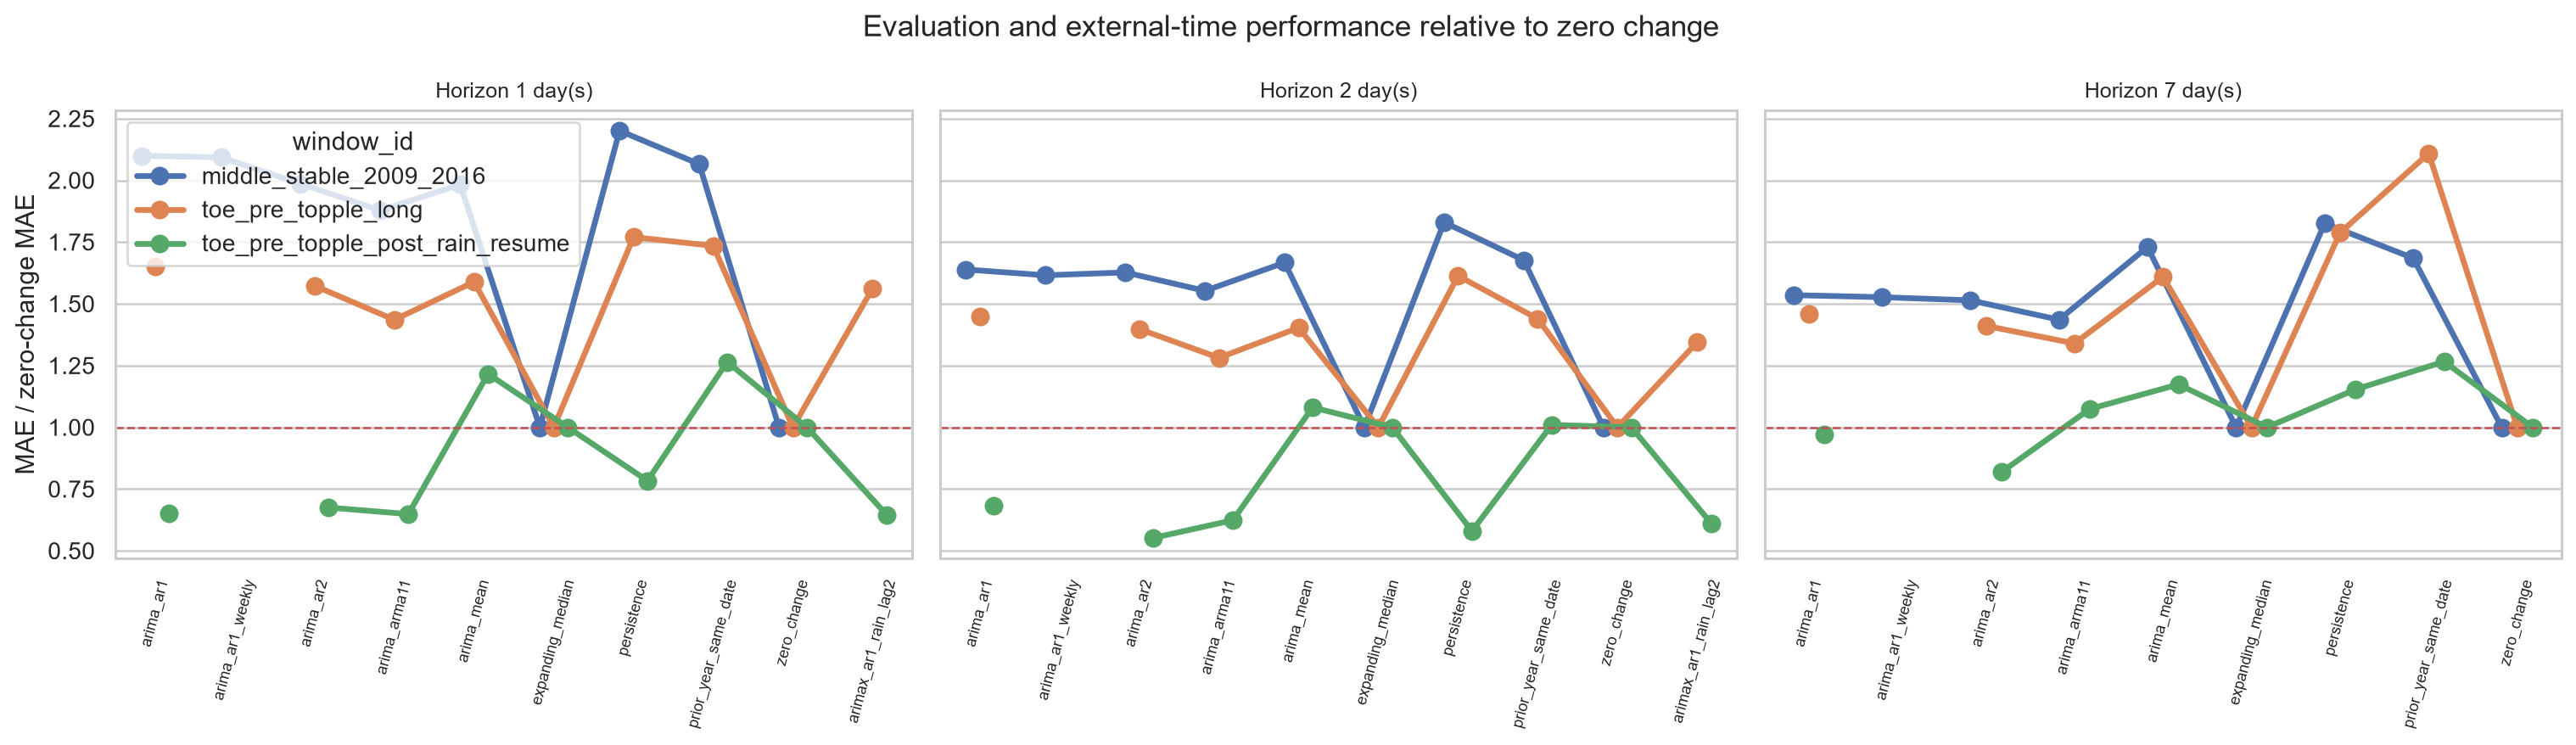

In [4]:
selection = pd.read_csv(TABLES / 'selection_decisions.csv')
display(selection)
display(Image(filename=str(FIGURES / '01_validation_mae.png')))
display(Image(filename=str(FIGURES / '02_relative_mae_to_zero.png')))

## Rain-conditioned forecasting and forecast-time availability

The toe ARIMAX is an AR(1) target model plus rain lag 2. That rain value is already observed at horizons 1 and 2, but would be future information at horizon 7; the missing horizon-7 forecast is intentional. In the long-window later evaluation, both available ARIMAX comparisons have paired uncertainty intervals wholly above zero, so rain does not add forecast skill over zero change under this design.

In [5]:
uncertainty = pd.read_csv(TABLES / 'forecast_comparison_uncertainty.csv')
display(
    uncertainty.loc[
        (uncertainty['stage'] == 'evaluation')
        & uncertainty['model_id'].isin(
            ['arima_ar1', 'arima_ar2', 'arima_arma11', 'persistence', 'arimax_ar1_rain_lag2']
        )
    ]
)

,window_id,target_id,stage,horizon_days,model_id,reference_model_id,common_origin_count,mean_absolute_error_difference,block_length_origins,bootstrap_replicates,bootstrap_seed,difference_ci_low,difference_ci_high
0,middle_stable_2009_2016,mid_E2_B,evaluation,1,arima_ar1,zero_change,61,0.061909,3,1000,170,0.040766,0.083489
2,middle_stable_2009_2016,mid_E2_B,evaluation,1,arima_ar2,zero_change,58,0.056134,3,1000,170,0.042245,0.075749
3,middle_stable_2009_2016,mid_E2_B,evaluation,1,arima_arma11,zero_change,61,0.049439,3,1000,170,0.036836,0.064918
6,middle_stable_2009_2016,mid_E2_B,evaluation,1,persistence,zero_change,61,0.067623,3,1000,170,0.039548,0.095575
9,middle_stable_2009_2016,mid_E2_B,evaluation,2,arima_ar1,zero_change,61,0.044417,3,1000,170,0.026300,0.059488
11,middle_stable_2009_2016,mid_E2_B,evaluation,2,arima_ar2,zero_change,58,0.041771,3,1000,170,0.028290,0.060197
12,middle_stable_2009_2016,mid_E2_B,evaluation,2,arima_arma11,zero_change,61,0.038416,3,1000,170,0.023364,0.052477
15,middle_stable_2009_2016,mid_E2_B,evaluation,2,persistence,zero_change,61,0.057705,3,1000,170,0.031557,0.080576
18,middle_stable_2009_2016,mid_E2_B,evaluation,7,arima_ar1,zero_change,58,0.037165,3,1000,170,0.024601,0.049675
20,middle_stable_2009_2016,mid_E2_B,evaluation,7,arima_ar2,zero_change,55,0.035544,3,1000,170,0.020768,0.047877


## Calibration, residuals, regimes, and stability

Intervals use prior realized residuals for baselines and model-based state-space distributions for ARIMA/ARIMAX. Retained dynamic-model intervals are mostly conservative. Approximate residual dependence is limited, but several toe residual distributions are heavy-tailed. Water-year and early/late errors vary, and early expanding coefficient paths shift sharply before the later estimates settle. Later tightness is not whole-record stability.

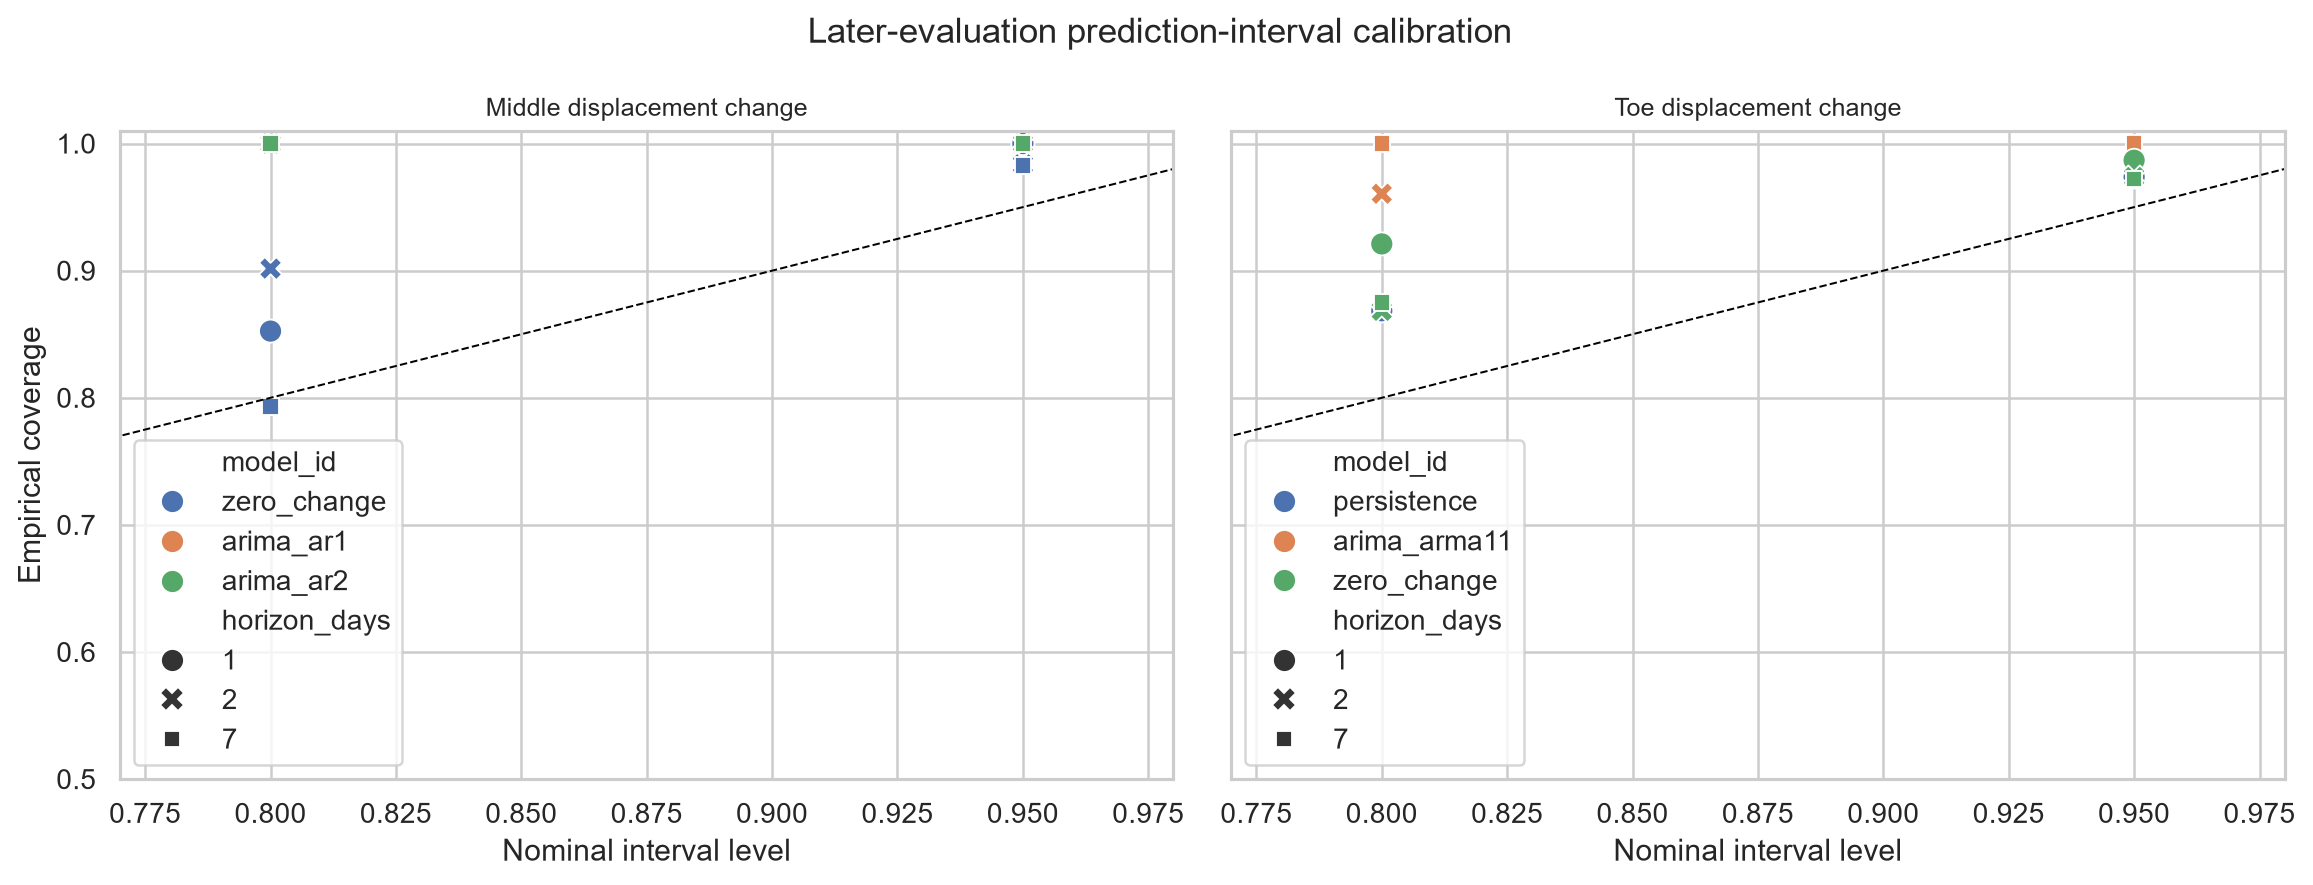

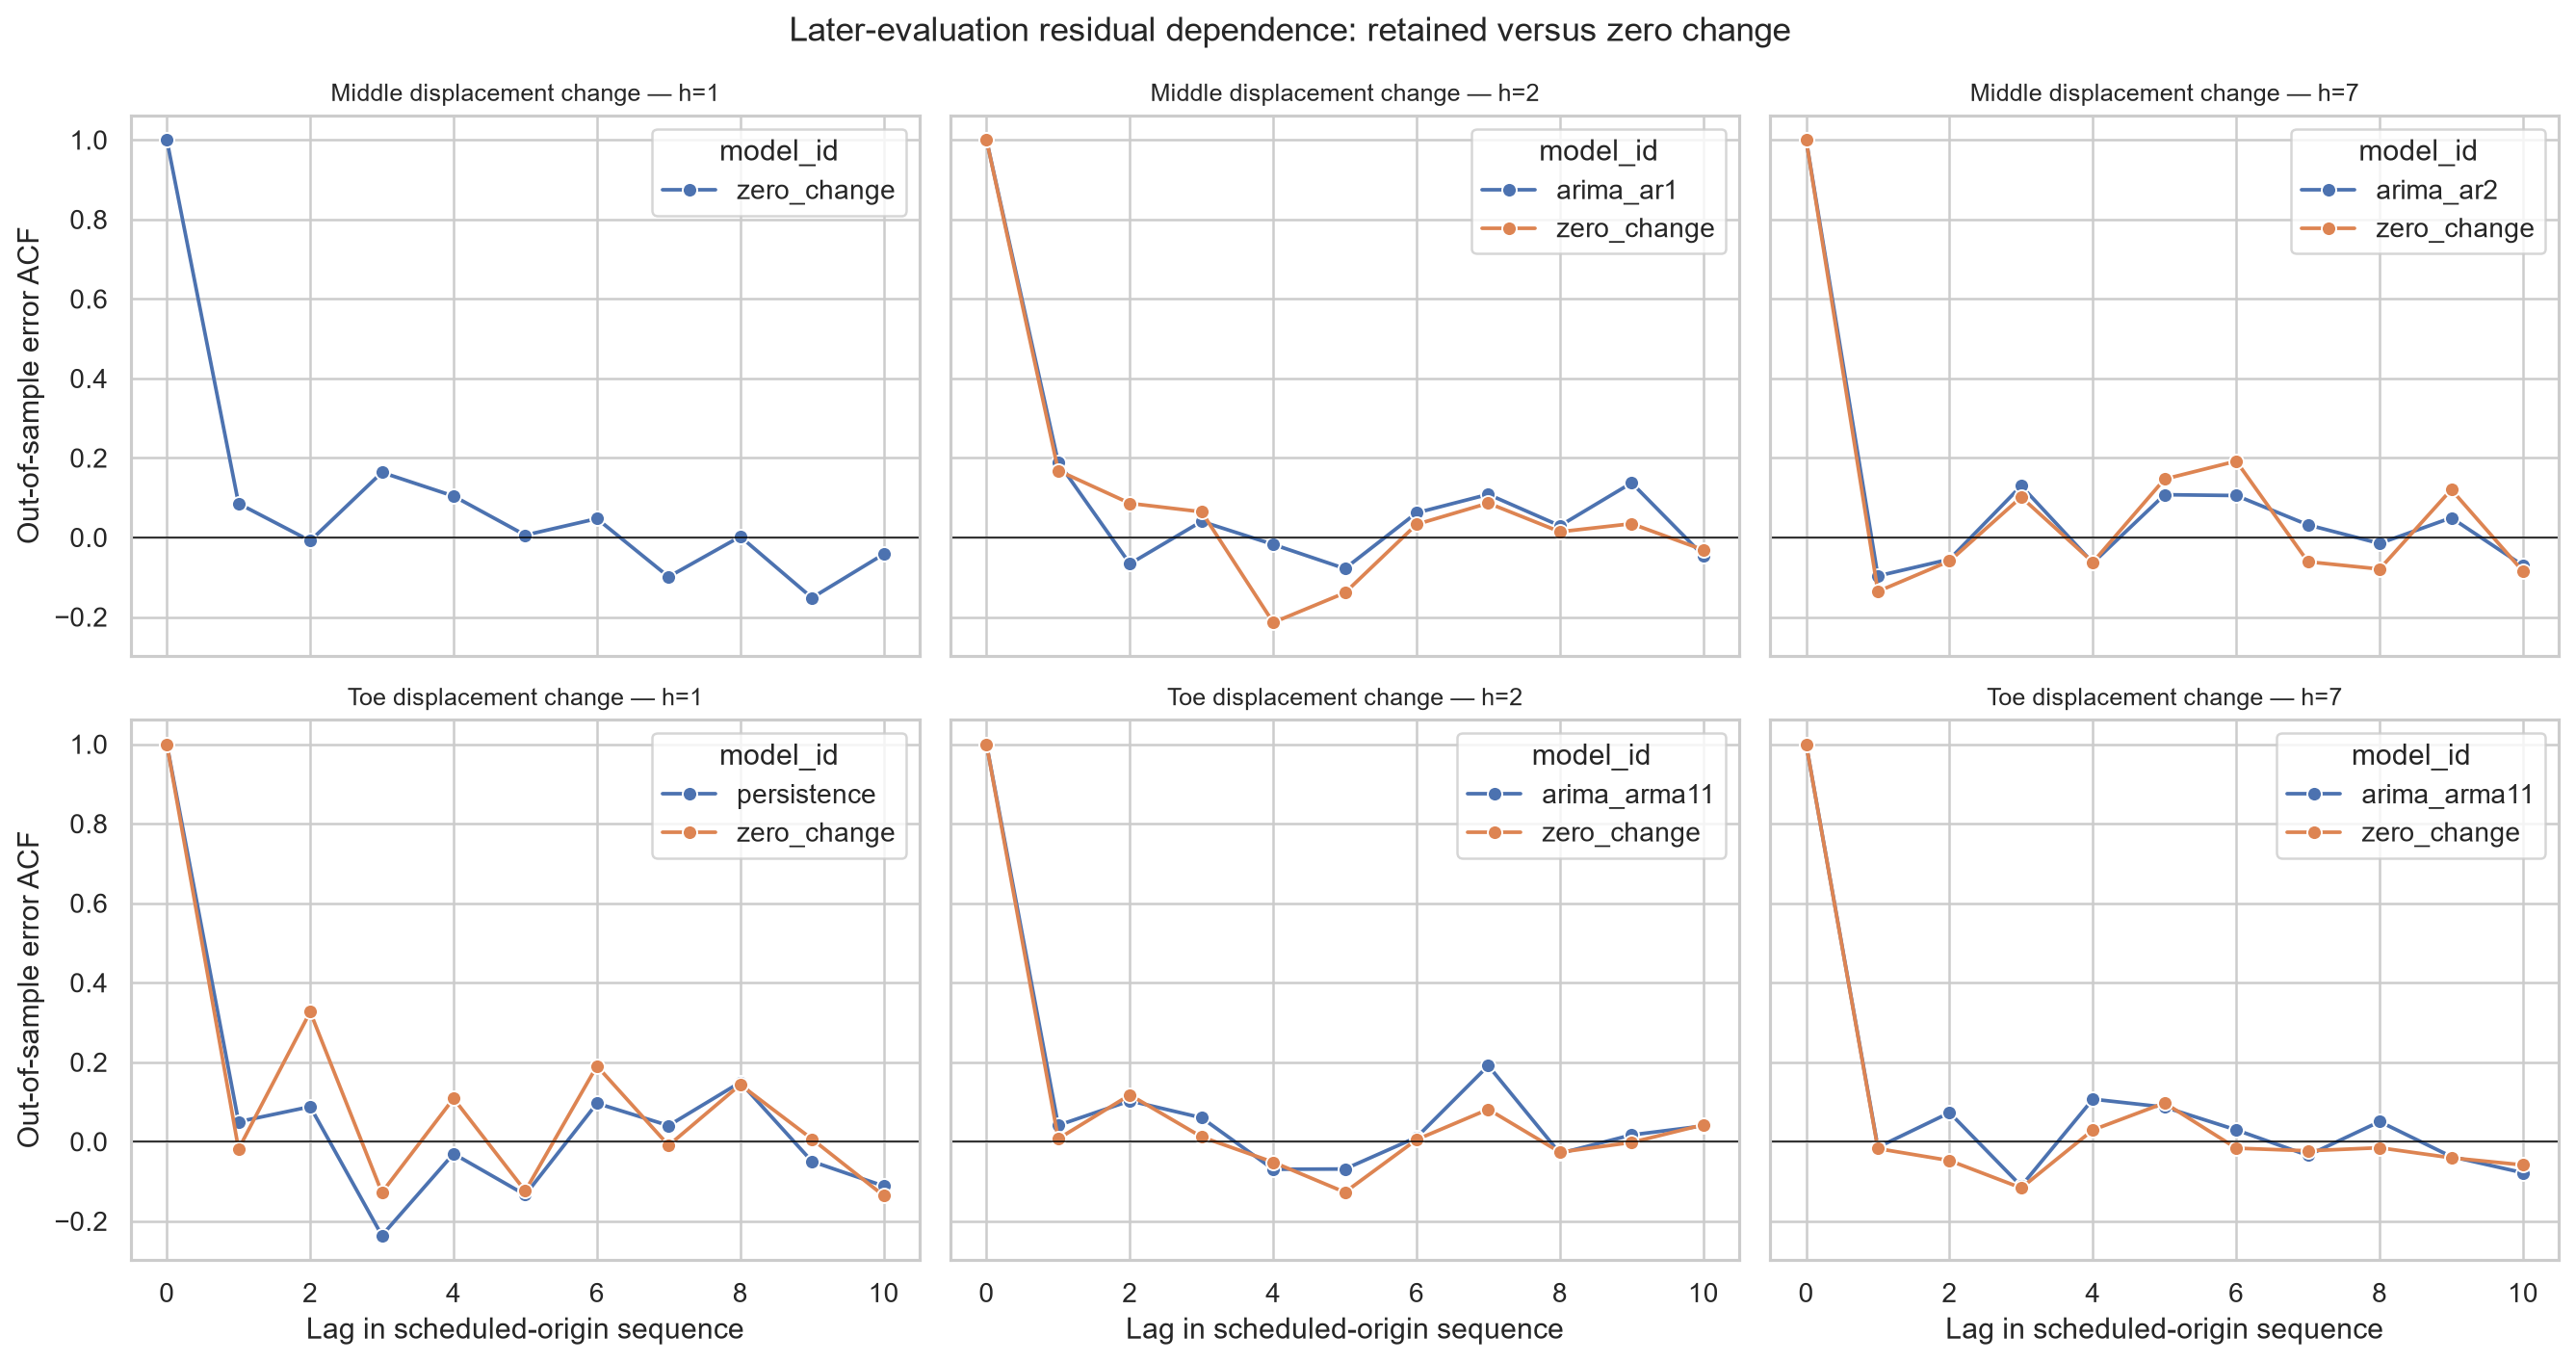

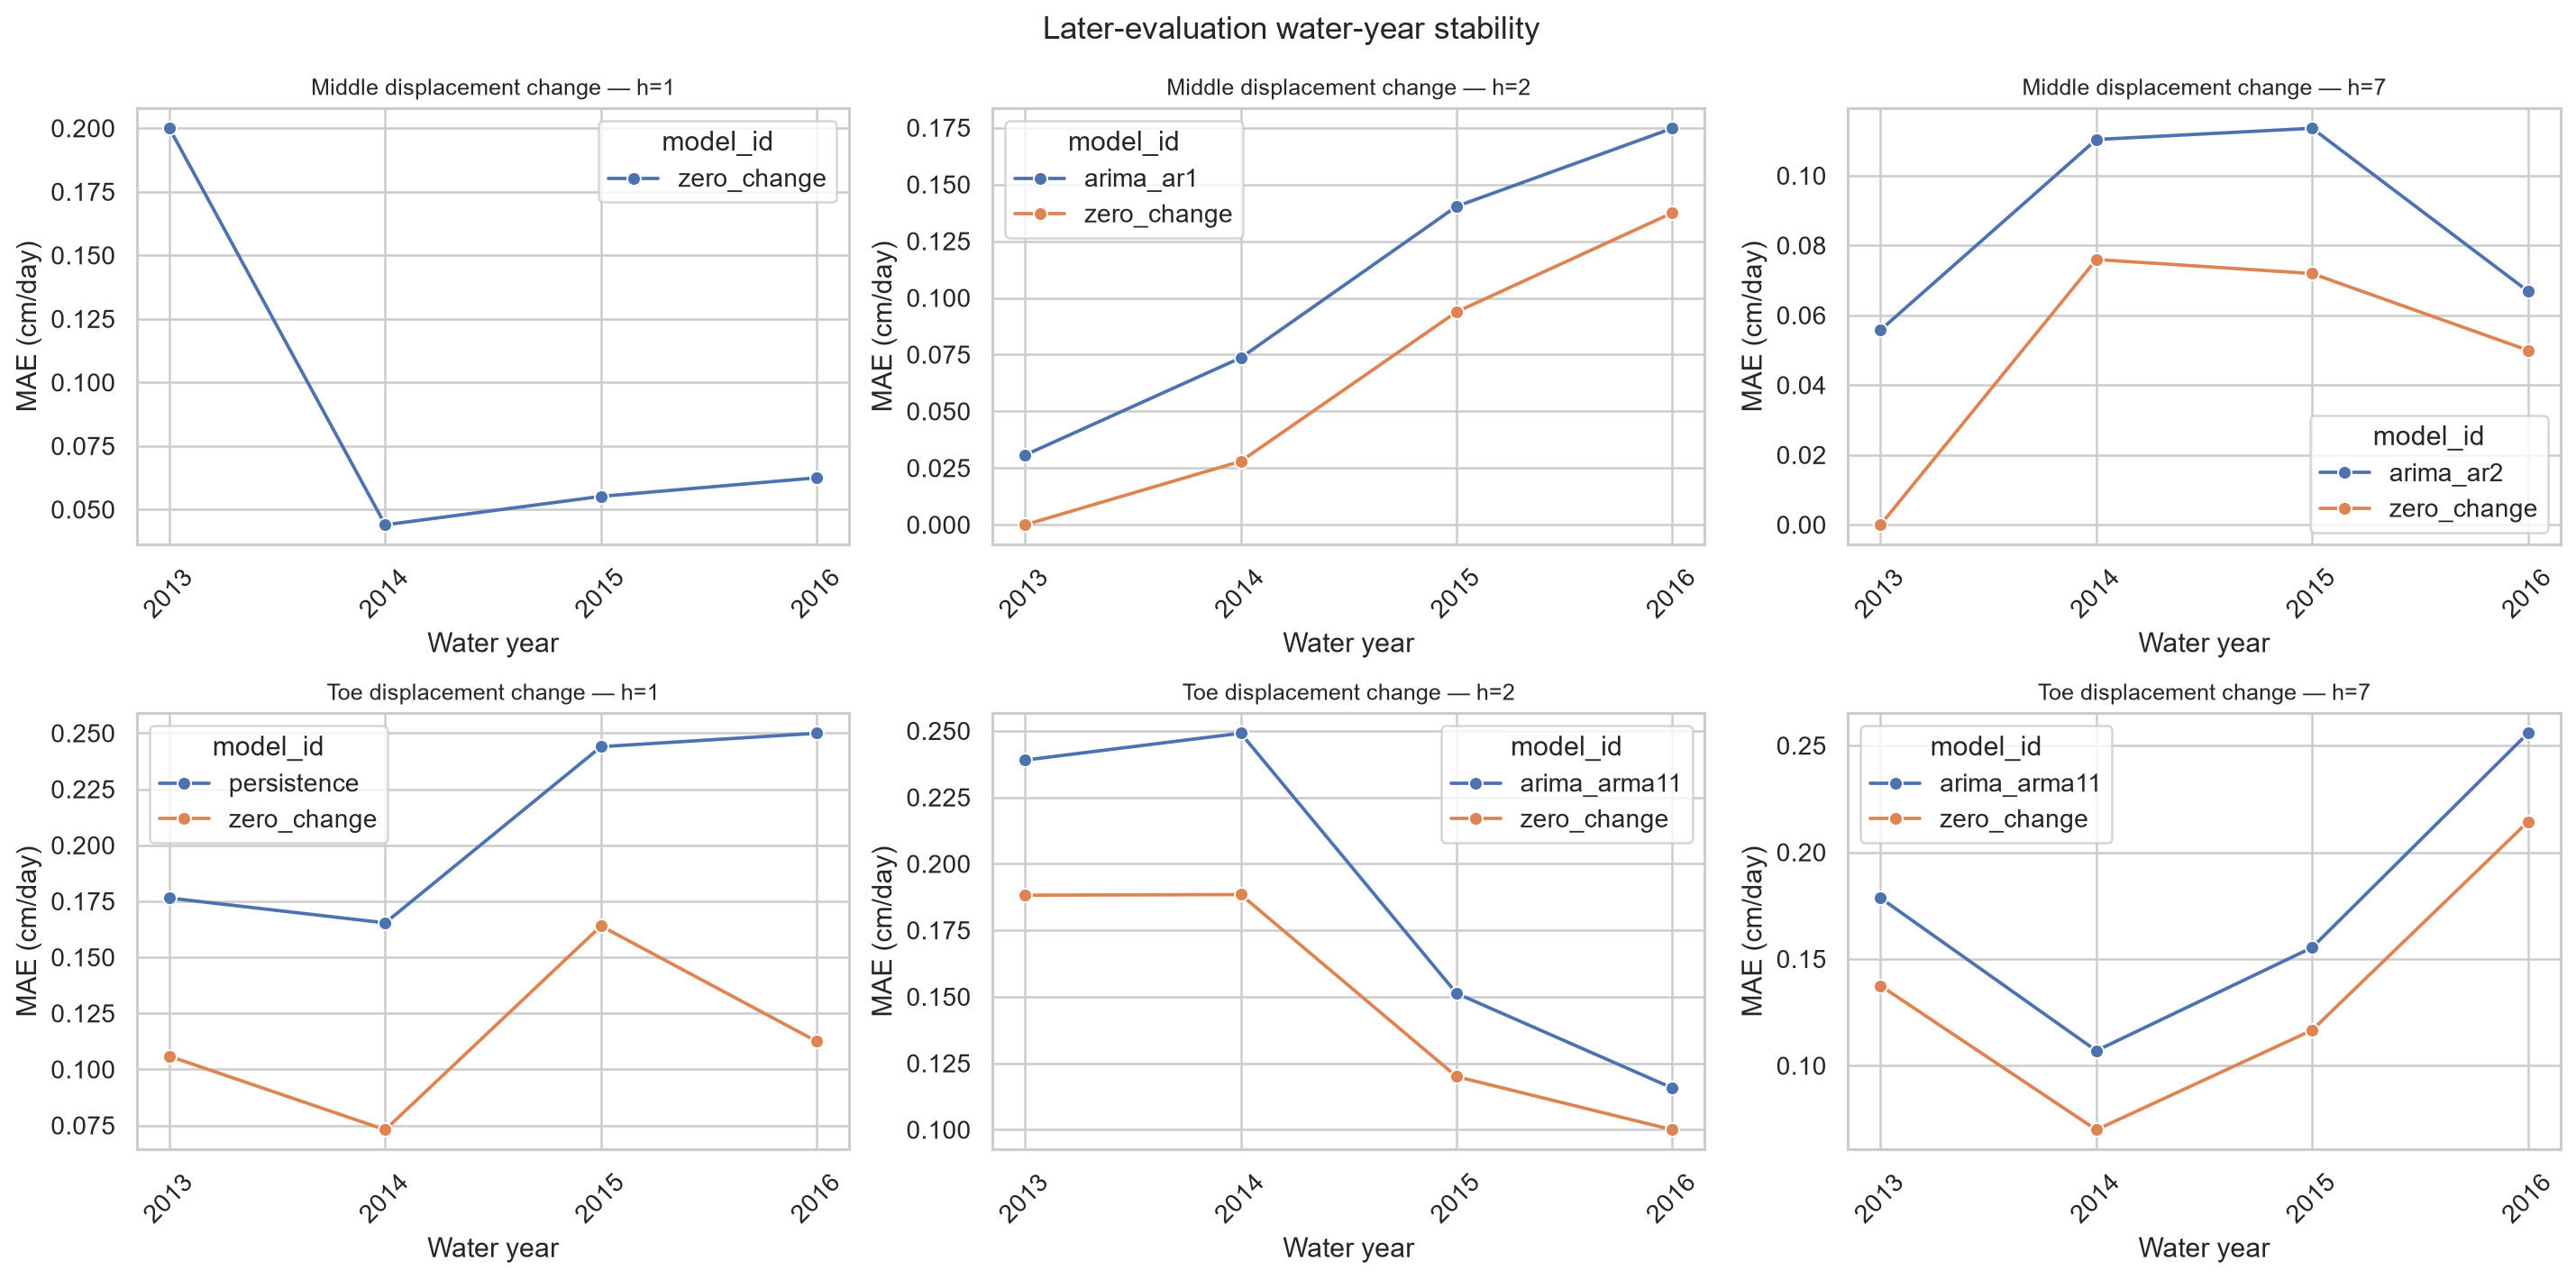

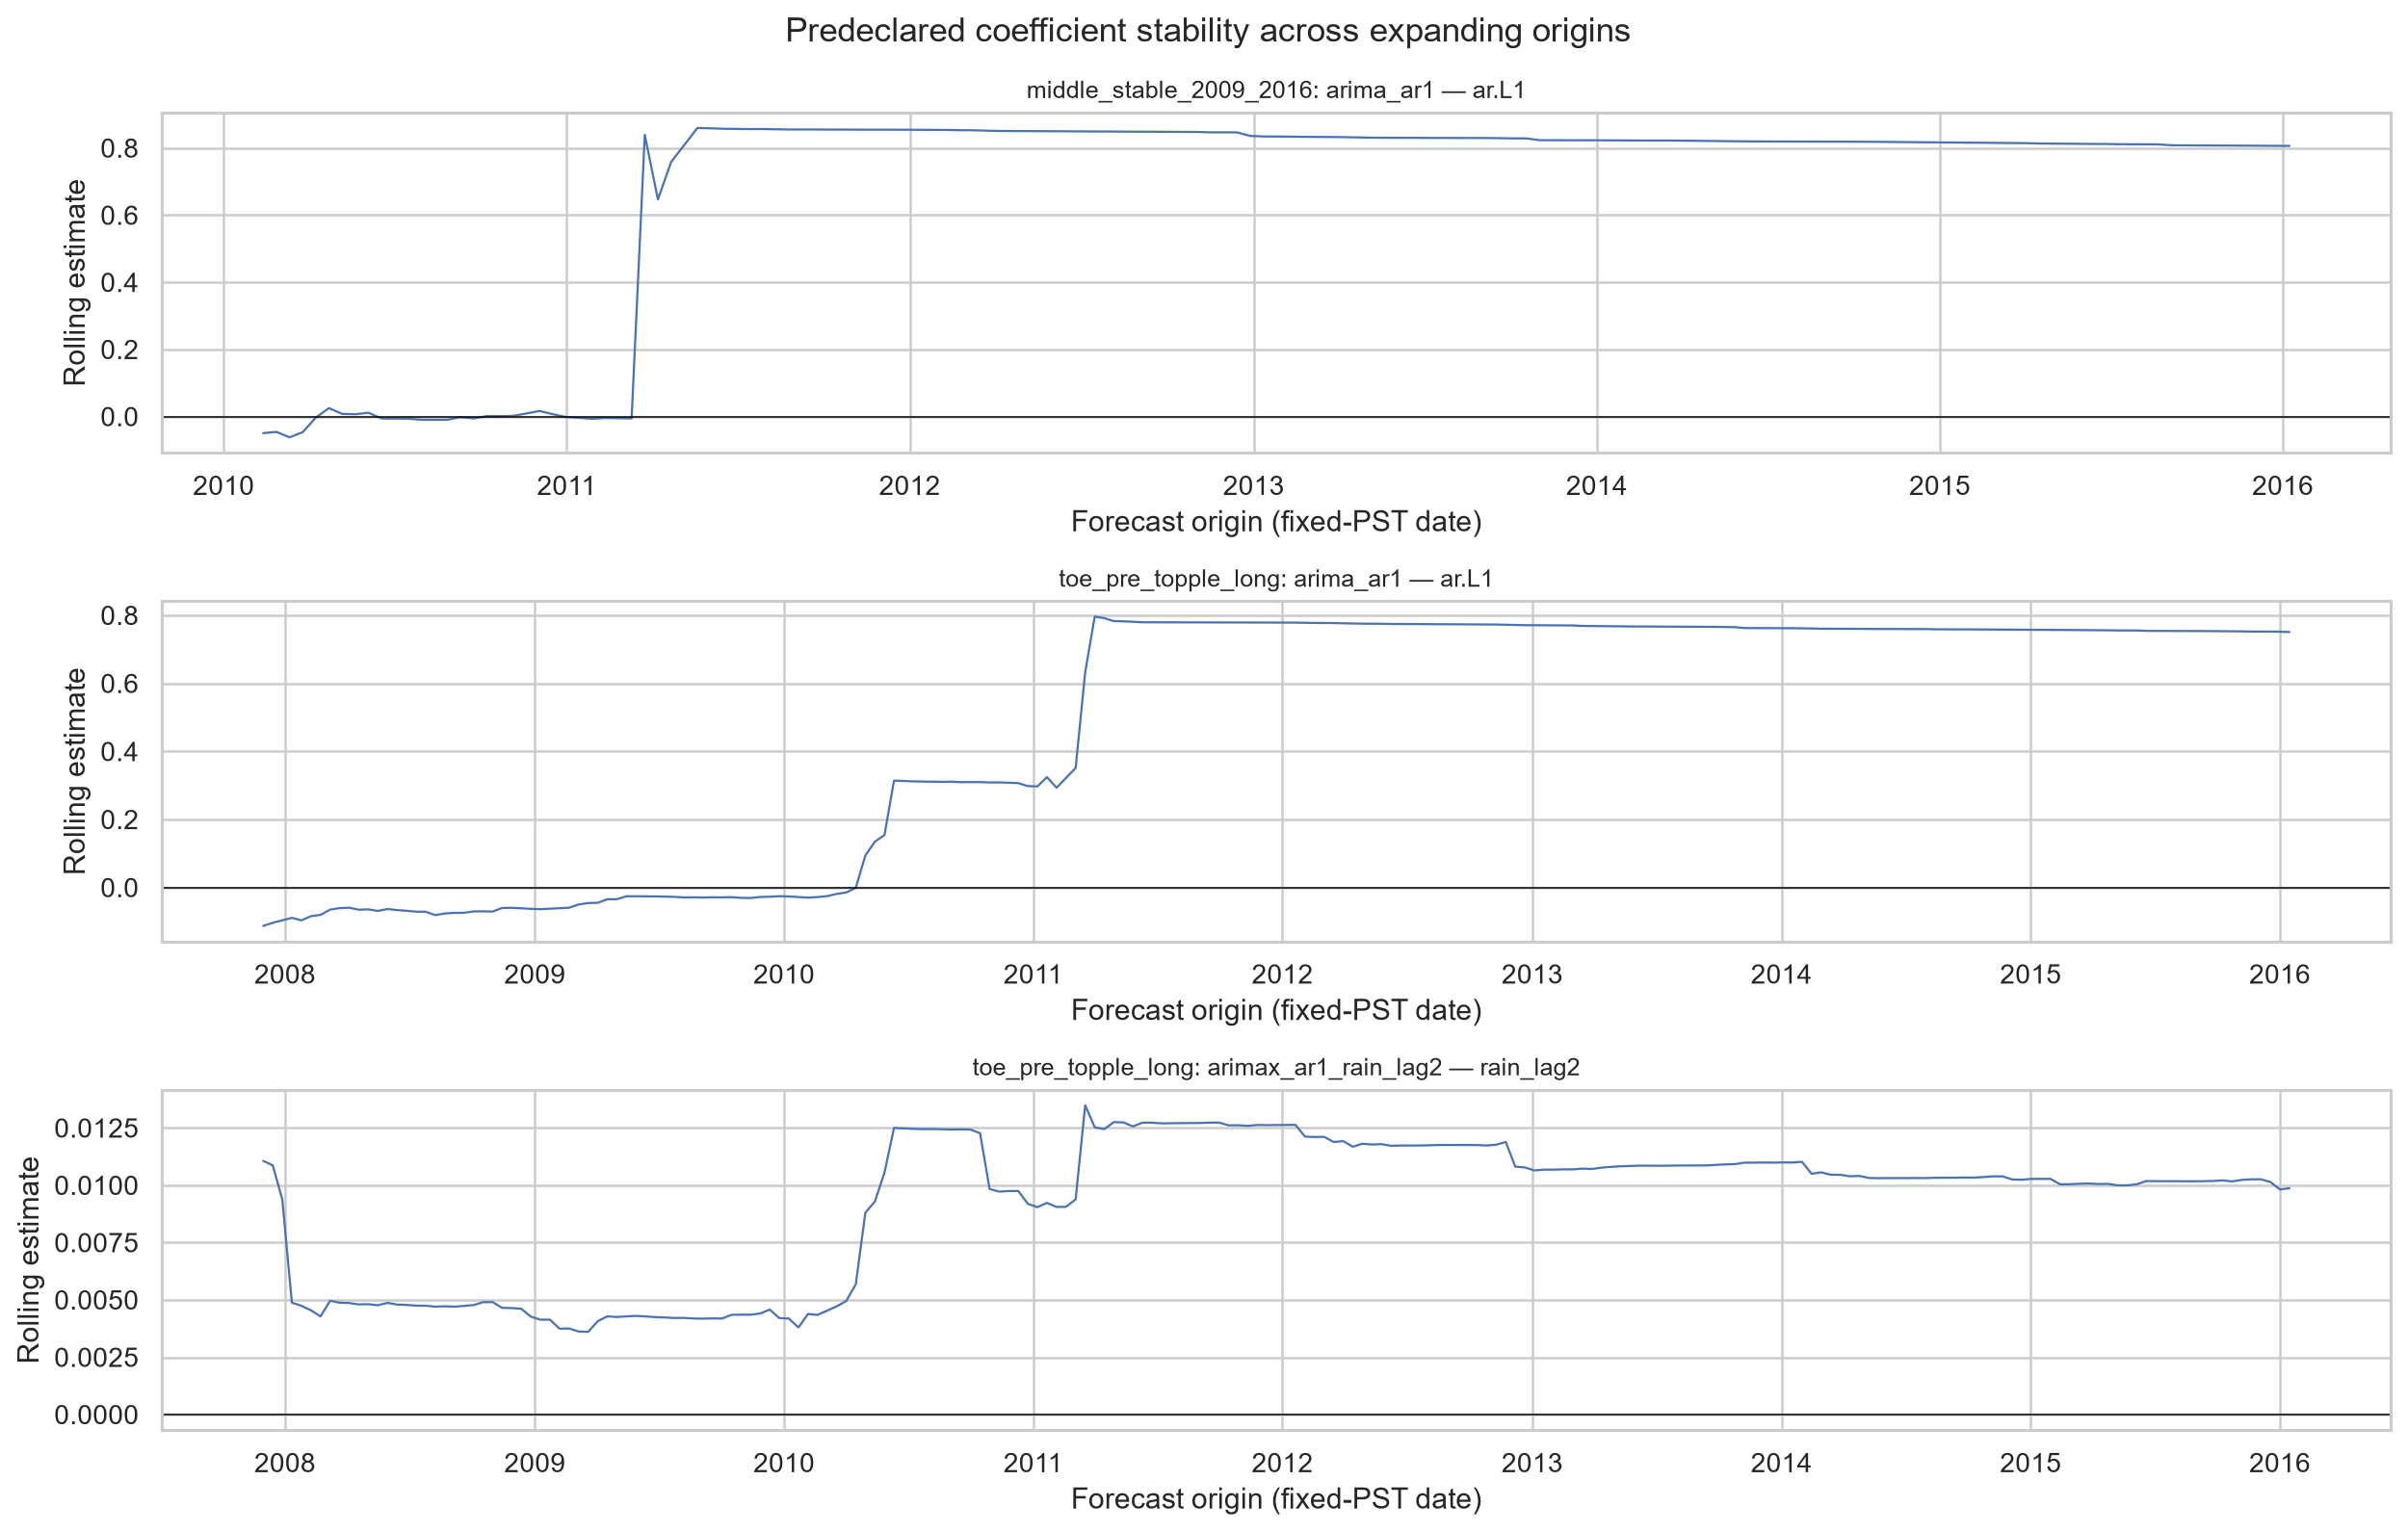

In [6]:
display(Image(filename=str(FIGURES / '03_interval_calibration.png')))
display(Image(filename=str(FIGURES / '04_retained_residual_acf.png')))
display(Image(filename=str(FIGURES / '05_water_year_stability.png')))
display(Image(filename=str(FIGURES / '06_coefficient_stability.png')))

## Coverage and explicit failures

Every scheduled attempt receives a status. Ineligible target paths, forecast-time feature unavailability, and numerical fit failures remain distinct; no alternative model silently replaces a failure. The absent ARIMAX horizon-7 bars are the expected contract outcome.

,model_id,status,attempt_count
0,arima_ar1,fit_failure,6
1,arima_ar1,ineligible_core_origin,104
2,arima_ar1,ok,1084
3,arima_ar1_weekly,ineligible_core_origin,34
4,arima_ar1_weekly,ok,431
5,arima_ar2,fit_failure,18
6,arima_ar2,ineligible_core_origin,104
7,arima_ar2,ok,1072
8,arima_arma11,fit_failure,6
9,arima_arma11,ineligible_core_origin,104


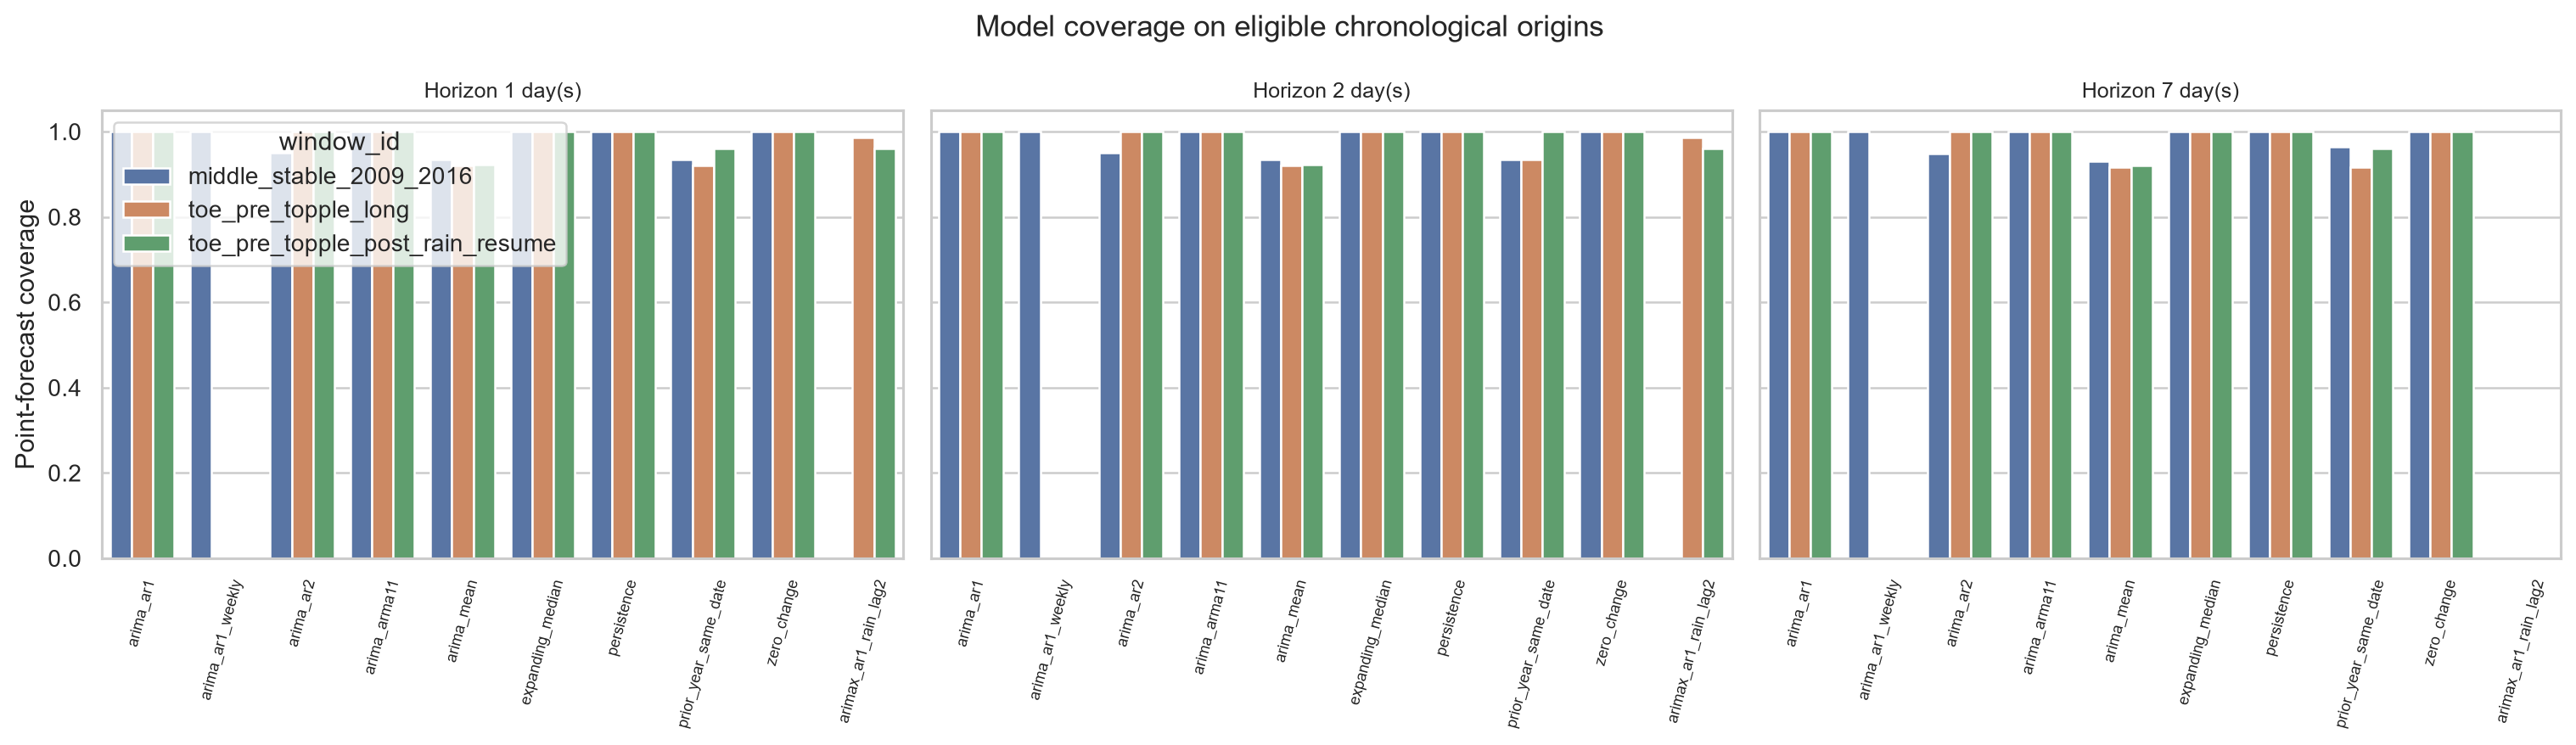

In [7]:
coverage = pd.read_csv(TABLES / 'model_coverage_failures.csv')
display(
    coverage.groupby(['model_id', 'status'], as_index=False)['attempt_count']
    .sum()
    .sort_values(['model_id', 'status'])
)
display(Image(filename=str(FIGURES / '09_forecast_coverage_failures.png')))

## Changepoints are sensitivity results, not physical regimes

Detection is restricted to exact eligible runs of at least 180 days, with no crossing of water years or sensor segments. Dates within ±7 days are grouped. Only four of 42 groups are supported by both PELT and binary segmentation; most are method-specific or unstable. Event alignment supplies context only and does not attribute cause.

,sensitivity_stability,context_classification,size
0,method_stable,event_aligned,3
1,method_stable,unexplained,1
2,unstable,event_aligned,6
3,unstable,unexplained,8
4,within_method_only,event_aligned,14
5,within_method_only,unexplained,10


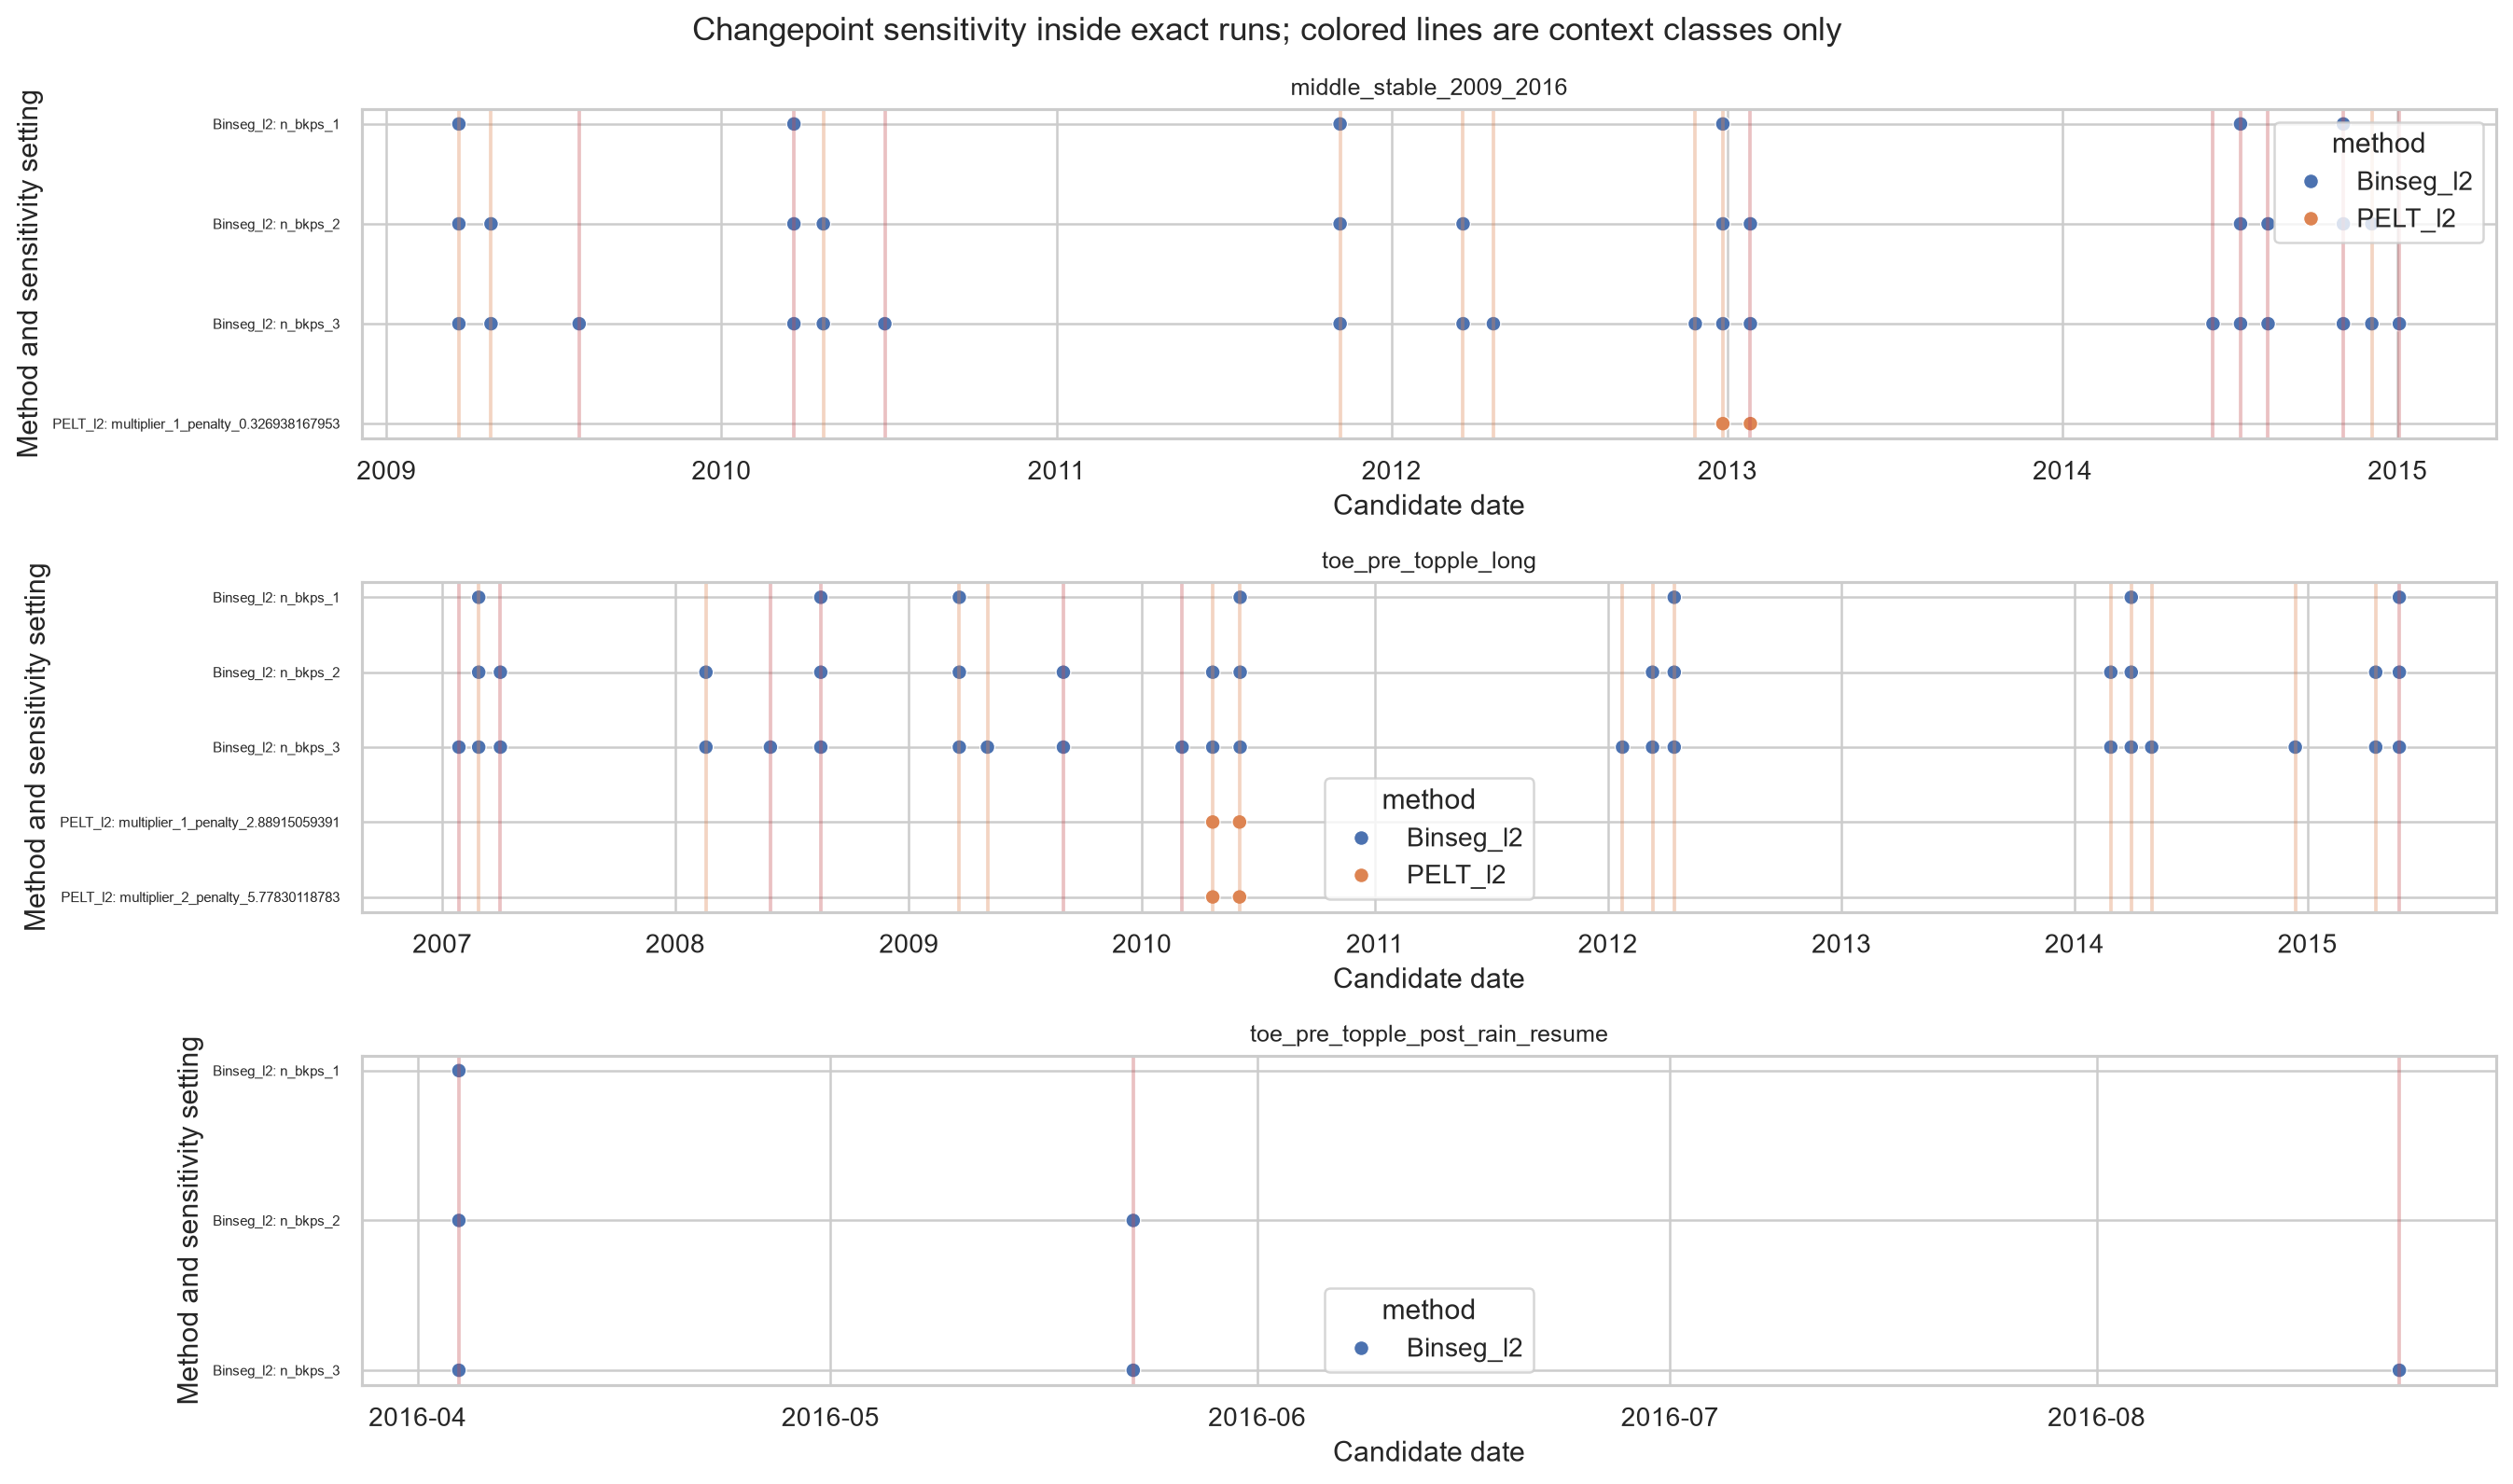

In [8]:
candidates = pd.read_csv(TABLES / 'changepoint_candidates.csv')
display(
    candidates.groupby(
        ['sensitivity_stability', 'context_classification'], as_index=False
    ).size()
)
display(Image(filename=str(FIGURES / '07_changepoint_sensitivity.png')))

## Why chronological validation matters

The seed-170 example is synthetic—not USGS data. A random split allows later-regime values into training and makes the same mean model appear much more accurate than a chronological split taken before the shift.

,data_origin,validation_design,sample_size,regime_shift_step,training_count,test_count,training_includes_post_shift,mae,rmse,bias
0,synthetic_seed_170_not_usgs,chronological_split,300,220,210,90,False,4.695689,4.996290,4.629283
1,synthetic_seed_170_not_usgs,random_split_leaks_later_regime,300,220,210,90,True,2.022629,2.492346,0.255913


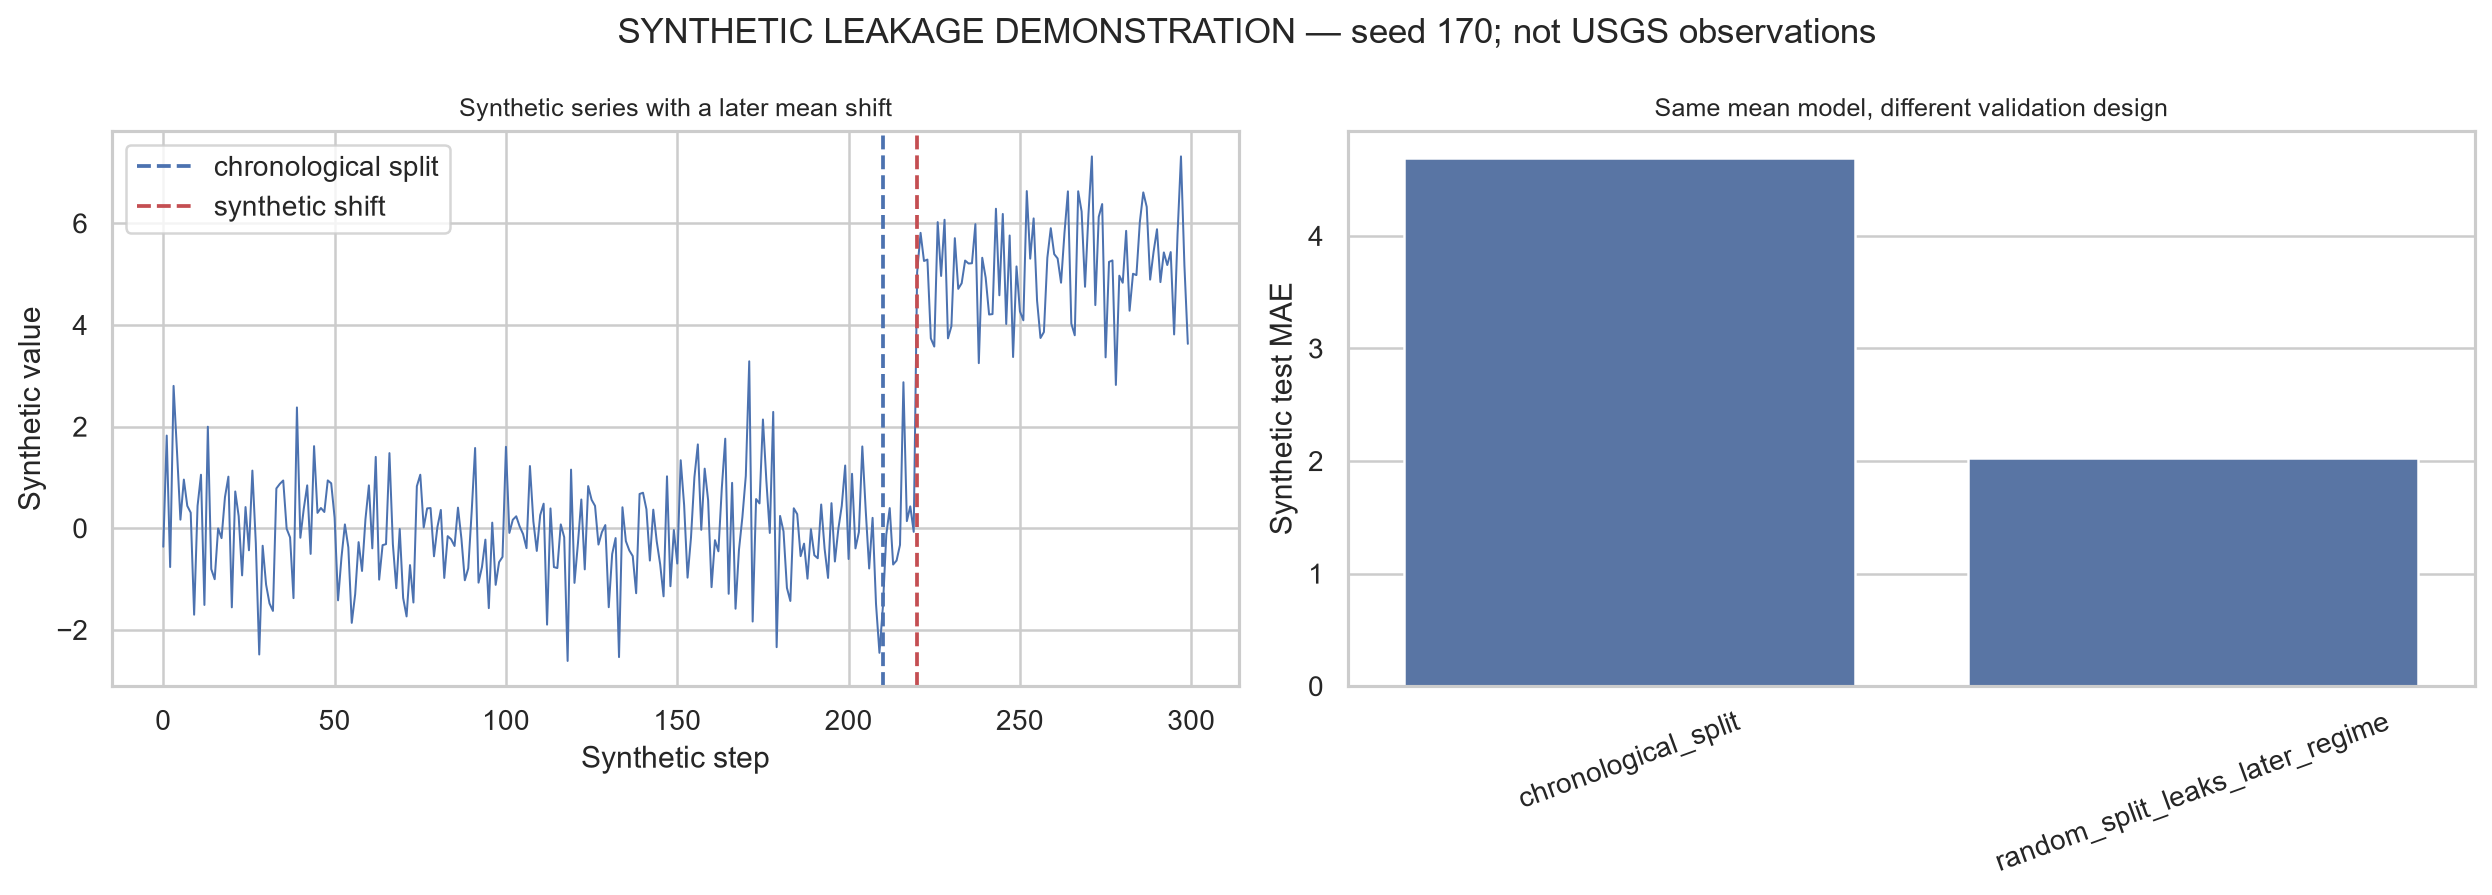

In [9]:
display(pd.read_csv(TABLES / 'synthetic_leakage_demo.csv'))
display(Image(filename=str(FIGURES / '08_synthetic_leakage.png')))

## Interpretation boundary

Observed data are the released values, timestamps, gaps, and instrument regimes. Statistical inference comprises the frozen rolling errors, intervals, residual diagnostics, coefficient paths, and algorithmic changepoints. Engineering interpretation may discuss why rare excursions make zero change a strong MAE benchmark or why stability could vary. Claims about infiltration paths, deformation mechanisms, causes, thresholds, alarms, or design remain speculation or out of scope. The final Phase 5 report preserves these boundaries without changing the analysis.